In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# Define the endpoint and parameters
endpoint = 'https://archive-api.open-meteo.com/v1/archive'
params = {
'latitude': -37.8136, # Latitude for Melbourne
'longitude': 144.9631, # Longitude for Melbourne
'start_date': (datetime(2026,6,1)).strftime('%Y-%m-%d'),
'end_date': (datetime(2026,8,31)).strftime('%Y-%m-%d'),
'hourly': 'temperature_2m',
'timezone': 'Australia/Melbourne'
}

In [3]:
# Make the API call
response = requests.get(endpoint, params=params)
wdata = response.json()
# Extract the relevant data
timestamps = [datetime.fromisoformat(item) for item in wdata['hourly']['time']]
temperatures = wdata['hourly']['temperature_2m']
# Create a DataFrame
wdf = pd.DataFrame({
'Date': timestamps,
'Temp': temperatures
})

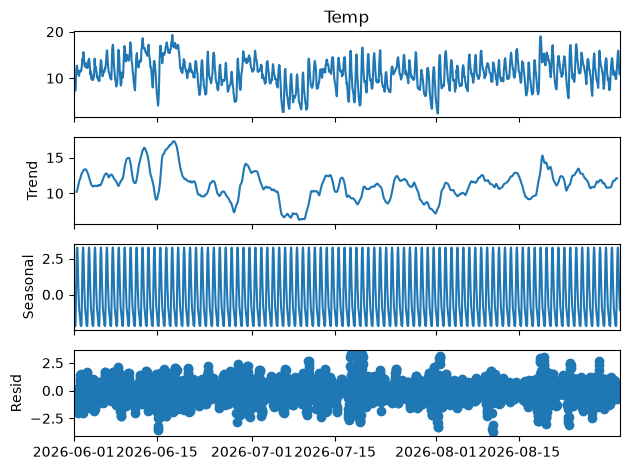

In [4]:
# Set the Date column as the index
wdf.set_index('Date', inplace=True)
# Perform seasonal decomposition
decomp = seasonal_decompose(wdf['Temp'], model='additive', period=24)
# Assuming hourly data with daily seasonality
# Plot the decomposed components
decomp.plot()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Split data into training and test sets
train_size = int(len(wdf) * 0.8)
train, test = wdf['Temp'][:train_size], wdf['Temp'][train_size:]
# Fit the model on the training set
arimamodel_510 = ARIMA(train, order=(5, 1, 0))
arimamodel_fit_510 = arimamodel_510.fit()
# Make predictions on the test set
predictions_510 = arimamodel_fit_510.forecast(steps=len(test))

/Users/hanskonradpujalte/Documents/Artificial-Intelligence/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/hanskonradpujalte/Documents/Artificial-Intelligence/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/hanskonradpujalte/Documents/Artificial-Intelligence/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [ ]:
# Split data into training and test sets
train_size = int(len(wdf) * 0.8)
train, test = wdf['Temp'][:train_size], wdf['Temp'][train_size:]
# Fit the model on the training set
arimamodel_111 = ARIMA(train, order=(1, 1, 1))
arimamodel_fit_111 = arimamodel_111.fit()
# Make predictions on the test set
predictions_111 = arimamodel_fit_111.forecast(steps=len(test))

In [ ]:
# Split data into training and test sets
train_size = int(len(wdf) * 0.8)
train, test = wdf['Temp'][:train_size], wdf['Temp'][train_size:]
# Fit the model on the training set
arimamodel_212 = ARIMA(train, order=(2, 1, 2))
arimamodel_fit_212 = arimamodel_212.fit()
# Make predictions on the test set
predictions_212 = arimamodel_fit_212.forecast(steps=len(test))

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Assuming 'actual' and 'predictions' are arrays/lists of equal length
rmse_510 = np.sqrt(mean_squared_error(test, predictions_510))
rmse_111 = np.sqrt(mean_squared_error(test, predictions_111))
rmse_212 = np.sqrt(mean_squared_error(test, predictions_212))
print(f"RMSE (5_1_0): {rmse_510}")
print(f"RMSE (1_1_1): {rmse_111}")
print(f"RMSE (2_1_2): {rmse_212}")

RMSE: 3.9156936846603885
